# Projet de détection de fraude à l’assurance automobile

Ce projet porte sur la détection automatique de fraudes dans les demandes d’indemnisation liées à l’assurance automobile.

Le dataset utilisé contient des informations relatives :
- aux assurés,
- aux véhicules,
- aux contrats d’assurance,
- ainsi qu’aux déclarations de sinistre.

L’objectif est de construire un pipeline complet de Machine Learning capable de prédire si une demande d’indemnisation est frauduleuse ou non.

On  est face à un problème de classification binaire :
- `0` : demande non frauduleuse ;
- `1` : demande frauduleuse.

## Import des librairies

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import  LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, accuracy_score, recall_score, f1_score
from sklearn.metrics import roc_curve

## Chargement du dataset



In [3]:
path = "input/fraud_oracle.csv"
df = pd.read_csv(path)



## Analyse exploratoire des données

In [4]:
print("\nInformations sur les données:")
print(f" Shape : {df.shape}")
print("-"*70)
print(df.info())




Informations sur les données:
 Shape : (15420, 33)
----------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Month                 15420 non-null  str  
 1   WeekOfMonth           15420 non-null  int64
 2   DayOfWeek             15420 non-null  str  
 3   Make                  15420 non-null  str  
 4   AccidentArea          15420 non-null  str  
 5   DayOfWeekClaimed      15420 non-null  str  
 6   MonthClaimed          15420 non-null  str  
 7   WeekOfMonthClaimed    15420 non-null  int64
 8   Sex                   15420 non-null  str  
 9   MaritalStatus         15420 non-null  str  
 10  Age                   15420 non-null  int64
 11  Fault                 15420 non-null  str  
 12  PolicyType            15420 non-null  str  
 13  VehicleCategory       15420 non-null  s

In [5]:
print("\nStatistiques descriptives:")
print(df.describe())



Statistiques descriptives:
        WeekOfMonth  WeekOfMonthClaimed           Age  FraudFound_P  \
count  15420.000000        15420.000000  15420.000000  15420.000000   
mean       2.788586            2.693969     39.855707      0.059857   
std        1.287585            1.259115     13.492377      0.237230   
min        1.000000            1.000000      0.000000      0.000000   
25%        2.000000            2.000000     31.000000      0.000000   
50%        3.000000            3.000000     38.000000      0.000000   
75%        4.000000            4.000000     48.000000      0.000000   
max        5.000000            5.000000     80.000000      1.000000   

       PolicyNumber     RepNumber    Deductible  DriverRating          Year  
count  15420.000000  15420.000000  15420.000000  15420.000000  15420.000000  
mean    7710.500000      8.483268    407.704280      2.487808   1994.866472  
std     4451.514911      4.599948     43.950998      1.119453      0.803313  
min        1.000000 

In [6]:
print("\nVérifier si présence de valeurs nulles:")
print(df.isna().sum().sum())

#print("\nDetails:")
#print(df.isna().sum())


Vérifier si présence de valeurs nulles:
0


In [7]:

print(f"Colonnes: {list(df.columns)}")

num_colums = df.select_dtypes(include=np.number).columns.drop("FraudFound_P")
category_columns = df.select_dtypes(include=str).columns
print(f"Colonnes numériques: {list(num_colums)}")
print(f"Colonnes catégorielles: {list(category_columns)}")



Colonnes: ['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']
Colonnes numériques: ['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Year']
Colonnes catégorielles: ['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', '

/tmp/ipykernel_11483/824665327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='FraudFound_P', data=df, palette=["#23714F","#EB0784"])


Text(0.5, 1.0, 'Matrice de Corrélation')

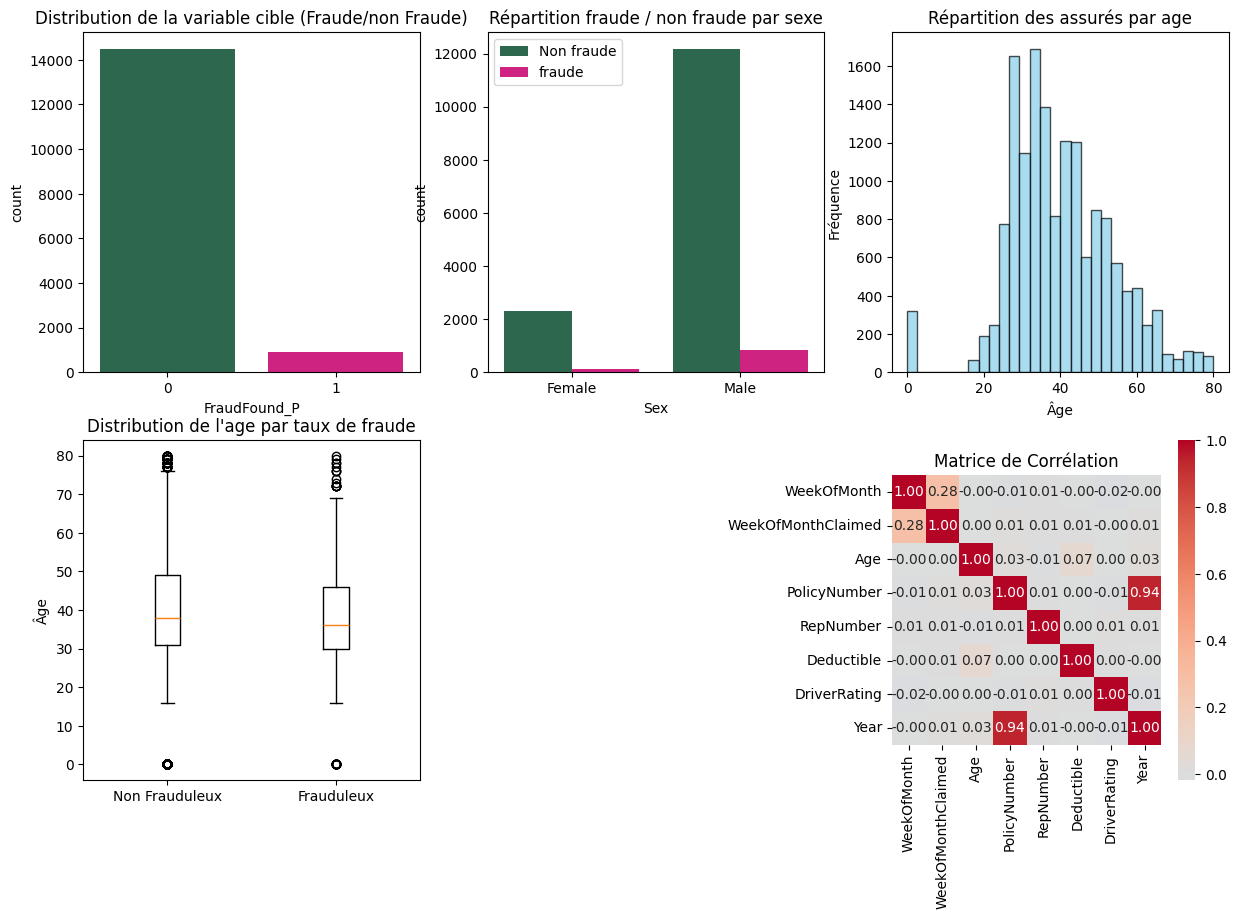

In [8]:
# EDA Visualisations
plt.figure(figsize=(20, 15))

# 1. Distribution de la variable cible
plt.subplot(3, 4, 1)
survival_counts = df['FraudFound_P'].value_counts()
sns.countplot(x='FraudFound_P', data=df, palette=["#23714F","#EB0784"])
plt.title('Distribution de la variable cible (Fraude/non Fraude)')

# 2. Taux de fraude par sexe
plt.subplot(3, 4, 2)
sns.countplot(x='Sex', hue='FraudFound_P',  data=df, palette=["#23714F","#EB0784"])
plt.title('Répartition fraude / non fraude par sexe')
plt.legend(['Non fraude', 'fraude'])
plt.xticks(rotation=0)


# 3. Distribution de l'âge
plt.subplot(3, 4, 3)
plt.hist(df['Age'].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Répartition des assurés par age')
plt.xlabel('Âge')
plt.ylabel('Fréquence')

# 4. Taux de fraude par âge (boxplot)
plt.subplot(3, 4, 5)
frauduleux_ages = df[df['FraudFound_P'] == 1]['Age'].dropna()
non_frauduleux_ages = df[df['FraudFound_P'] == 0]['Age'].dropna()
plt.boxplot([non_frauduleux_ages, frauduleux_ages], tick_labels=['Non Frauduleux', 'Frauduleux'])
plt.title("Distribution de l'age par taux de fraude")
plt.ylabel('Âge')

# Matrice de correlation
plt.subplot(3, 4, 7)
corr_matrix = df[num_colums].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Matrice de Corrélation')





In [13]:
# Valeur age à 0
print(f"Nombre de lignes ou âge est à 0 : {(df["Age"] == 0).sum()} soit {round((df["Age"] == 0).sum() * 100 /df.shape[0], 2)} %")



Nombre de lignes ou âge est à 0 : 320 soit 2.08 %


La variable Age contient des valeurs égales à 0 (~2% du dataset).
On peut supposer que ces valeurs ont été traitées comme données manquantes. Donc on va imputer ces valeurs par la médiane afin de limiter l’impact des valeurs extrêmes sur la distribution.

## Liste des colonnes à supprimer
- PolicyNumber, RepNumber : qui sont des identifiants et donc n'apportent pas valeur pour l'entrainement

⚠️ Colonnes à surveiller et voir s'il faut supprimer après entrainement  
- PoliceReportFiled: rapport de police déposé (potentiellement déposé après l'accident)
- WitnessPresent: Présence de témoin
- NumberOfSuppliments: nombre de justificatifs supplémentaires
- Make: Marque des voitures- nombre de catégories très élevées (19) pour oneHotEncoder. Mais la marque peut impacter la fraude.

In [10]:
# verifier les features catégorielles
print(df[category_columns].nunique().sort_values(ascending=False))

for column in category_columns:
    print(f" {column} : {df[column].unique()}")
    print(f"________________________________")



Make                    19
MonthClaimed            13
Month                   12
PolicyType               9
AgeOfPolicyHolder        9
AgeOfVehicle             8
DayOfWeekClaimed         8
DayOfWeek                7
VehiclePrice             6
AddressChange_Claim      5
Days_Policy_Accident     5
NumberOfCars             5
PastNumberOfClaims       4
NumberOfSuppliments      4
MaritalStatus            4
Days_Policy_Claim        4
BasePolicy               3
VehicleCategory          3
Sex                      2
AccidentArea             2
Fault                    2
AgentType                2
PoliceReportFiled        2
WitnessPresent           2
dtype: int64
 Month : <StringArray>
['Dec', 'Jan', 'Oct', 'Jun', 'Feb', 'Nov', 'Apr', 'Mar', 'Aug', 'Jul', 'May',
 'Sep']
Length: 12, dtype: str
________________________________
 DayOfWeek : <StringArray>
['Wednesday', 'Friday', 'Saturday', 'Monday', 'Tuesday', 'Sunday', 'Thursday']
Length: 7, dtype: str
________________________________
 Make : <Stri

## Vérifier la corrélation de certaines variables catégorielles avec la target


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18]),
 [Text(0, 0, 'Mecedes'),
  Text(1, 0, 'Accura'),
  Text(2, 0, 'Saturn'),
  Text(3, 0, 'Saab'),
  Text(4, 0, 'Ford'),
  Text(5, 0, 'Mercury'),
  Text(6, 0, 'BMW'),
  Text(7, 0, 'Honda'),
  Text(8, 0, 'Toyota'),
  Text(9, 0, 'Chevrolet'),
  Text(10, 0, 'Pontiac'),
  Text(11, 0, 'Mazda'),
  Text(12, 0, 'Nisson'),
  Text(13, 0, 'VW'),
  Text(14, 0, 'Dodge'),
  Text(15, 0, 'Jaguar'),
  Text(16, 0, 'Lexus'),
  Text(17, 0, 'Ferrari'),
  Text(18, 0, 'Porche')])

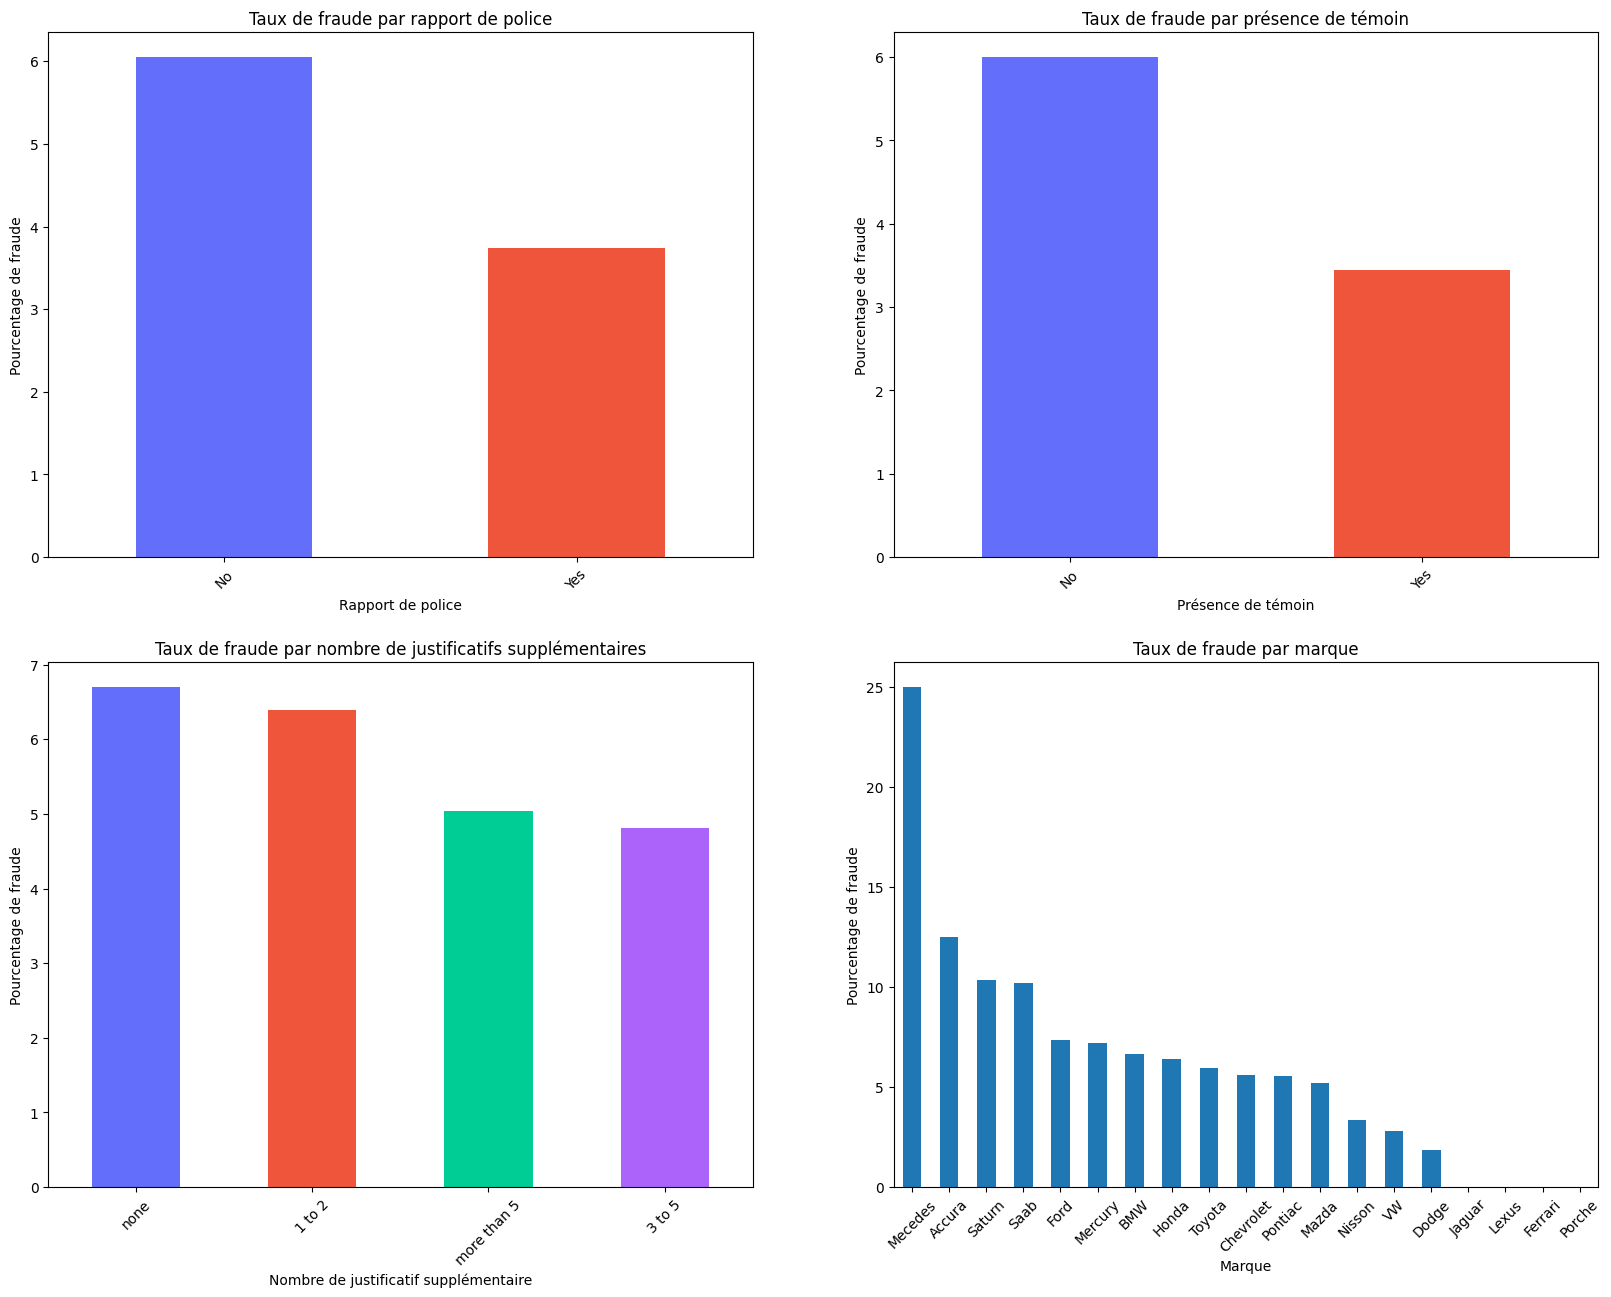

In [11]:
# PoliceReportFiled
plt.figure(figsize=(20, 15))

plt.subplot(2, 2, 1)
fraud_rate = (
    df.groupby("PoliceReportFiled")["FraudFound_P"]
    .mean()
    .sort_values(ascending=False)
    * 100
)
fraud_rate.plot(kind="bar",color= ['#636EFA', '#EF553B'])
plt.title("Taux de fraude par rapport de police")
plt.xlabel("Rapport de police")
plt.ylabel("Pourcentage de fraude")
plt.xticks(rotation=45)

# WitnessPresent

plt.subplot(2, 2, 2)
fraud_rate = (
    df.groupby("WitnessPresent")["FraudFound_P"]
    .mean()
    .sort_values(ascending=False)
    * 100
)
fraud_rate.plot(kind="bar", color= ['#636EFA', '#EF553B', ])
plt.title("Taux de fraude par présence de témoin")
plt.xlabel("Présence de témoin")
plt.ylabel("Pourcentage de fraude")
plt.xticks(rotation=45)

# NumberOfSuppliments
plt.subplot(2, 2, 3)
fraud_rate = (
    df.groupby("NumberOfSuppliments")["FraudFound_P"]
    .mean()
    .sort_values(ascending=False)
    * 100
)
fraud_rate.plot(kind="bar", color= ['#636EFA', '#EF553B',  '#00CC96', '#AB63FA'])
plt.title("Taux de fraude par nombre de justificatifs supplémentaires")
plt.xlabel("Nombre de justificatif supplémentaire")
plt.ylabel("Pourcentage de fraude")
plt.xticks(rotation=45)


plt.subplot(2, 2, 4)
fraud_rate = (
    df.groupby("Make")["FraudFound_P"]
    .mean()
    .sort_values(ascending=False)
    * 100
)
fraud_rate.plot(kind="bar")
plt.title("Taux de fraude par marque")
plt.xlabel("Marque")
plt.ylabel("Pourcentage de fraude")
plt.xticks(rotation=45)

## Split des données entrainement et de test

In [12]:
X = df.drop(columns=["PolicyNumber", "RepNumber", "FraudFound_P"])
y = df["FraudFound_P"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_colums = X_train.select_dtypes(include=np.number).columns
cat_colums = X_train.select_dtypes(include=str).columns

print(f"num_colums {len(num_colums)}")
print(f"cat_colums {len(cat_colums)}")
print(y_test.shape)
print(y_train.shape)


num_colums 6
cat_colums 24
(3084,)
(12336,)


## Utilisation des pipelines pour le preprocessing

### Liste des colonnes

In [ ]:
numeric_columns = ['WeekOfMonth', 'WeekOfMonthClaimed', 'Deductible', 'DriverRating', 'Year']
age_column = ['Age'] # Imputer special pour age
categoric_one_hot_columns = ["AccidentArea", "Sex", "MaritalStatus", "Fault", "PolicyType", 
                             "VehicleCategory", "AgentType", "BasePolicy","PoliceReportFiled","WitnessPresent", "Make"]
categoric_ordinal_columns = ["NumberOfCars", "VehiclePrice", "Days_Policy_Claim", 
                    "Days_Policy_Accident", "PastNumberOfClaims", "AgeOfVehicle", 
                    "AgeOfPolicyHolder", "AddressChange_Claim", "Month", "DayOfWeek", "DayOfWeekClaimed", "MonthClaimed", "NumberOfSuppliments"]

print(len(num_colums)+len(categoric_one_hot_columns)+len(categoric_ordinal_columns))
print(len(categoric_ordinal_columns))
print(df.shape)

26
12
(15420, 33)


### Pipeline pour les colonnes numériques

In [ ]:
numeric_pipe = Pipeline(steps=[('imputer', SimpleImputer()),('scaler', StandardScaler())])
age_numeric_pipe = Pipeline(steps=[('imputer', SimpleImputer(missing_values=0, strategy='median')),('scaler', StandardScaler()) ])

### Pipeline pour les colonnes catégorielles


In [ ]:
#OneHotEncoder
categoric_one_hot_pipe = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore')) ])

#OrdinalEncoder

NumberOfCars_order = ['1 vehicle', '2 vehicles', '3 to 4', '5 to 8', 'more than 8']
VehiclePrice_order = ['less than 20000','20000 to 29000', '30000 to 39000', '40000 to 59000', '60000 to 69000','more than 69000']
Days_Policy_Claim_order= ['none', '8 to 15', '15 to 30','more than 30' ]
Days_Policy_Accident_order= ['none', '1 to 7','8 to 15', '15 to 30','more than 30' ]
PastNumberOfClaims_order= ['none', '1', '2 to 4', 'more than 4']
AgeOfVehicle_order= [ 'new',   '2 years', '3 years', '4 years',  '5 years',  '6 years',     '7 years', 'more than 7'  ]
AgeOfPolicyHolder_order= ['16 to 17','18 to 20', '21 to 25','26 to 30', '31 to 35','36 to 40', '41 to 50', '51 to 65','over 65']
AddressChange_Claim_order= ['no change', 'under 6 months', '1 year', '2 to 3 years', '4 to 8 years']
Month_order= ['Jan', 'Feb', 'Mar','Apr', 'May','Jun','Jul', 'Aug','Sep','Oct', 'Nov','Dec' ]
DayOfWeek_order= ['Sunday','Monday','Tuesday', 'Wednesday', 'Thursday','Friday', 'Saturday' ]
DayOfWeekClaimed_order= ['0', 'Sunday','Monday','Tuesday', 'Wednesday', 'Thursday','Friday', 'Saturday' ]
MonthClaimed_order= ['0', 'Jan', 'Feb', 'Mar','Apr', 'May','Jun','Jul', 'Aug','Sep','Oct', 'Nov','Dec' ]
NumberOfSuppliments_order = ['none','1 to 2', '3 to 5','more than 5'  ]

ordinal_encoder_pipe = Pipeline([ ('imputer', SimpleImputer(strategy='most_frequent'),
                                   ("encoder", OrdinalEncoder(
            categories=[
                NumberOfCars_order, 
                VehiclePrice_order, 
                Days_Policy_Claim_order,
                Days_Policy_Accident_order,
                PastNumberOfClaims_order,
                AgeOfVehicle_order,
                AgeOfPolicyHolder_order,
                AddressChange_Claim_order,
                Month_order,
                DayOfWeek_order,
                DayOfWeekClaimed_order,
                MonthClaimed_order,
                NumberOfSuppliments_order
            ]
        )
    ) )
])



### Utilisation du columnTranformer

In [ ]:
preprocessor = ColumnTransformer([
    
    ("num", numeric_pipe, numeric_columns),

    ("age", age_numeric_pipe, age_column),
    
    ("onehot", categoric_one_hot_pipe, categoric_one_hot_columns),

    ("ordinale", ordinal_encoder_pipe, categoric_ordinal_columns)
])

## Modèle Baseline
La régression logistique est utilisée comme baseline car elle fournit un modèle simple, rapide et interprétable pour une tâche de classification binaire. Elle permet d’établir un premier niveau de performance avant de comparer des modèles plus complexes capables de capturer des relations non linéaires.


Création du pipeline avec préprocessing et modèle...


              precision    recall  f1-score   support

           0       0.99      0.59      0.74      2899
           1       0.13      0.93      0.22       185

    accuracy                           0.61      3084
   macro avg       0.56      0.76      0.48      3084
weighted avg       0.94      0.61      0.71      3084



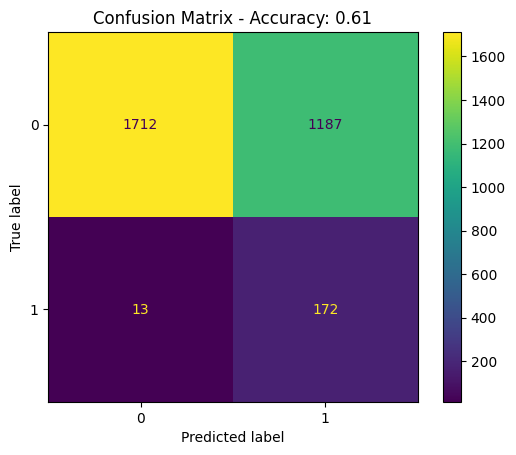

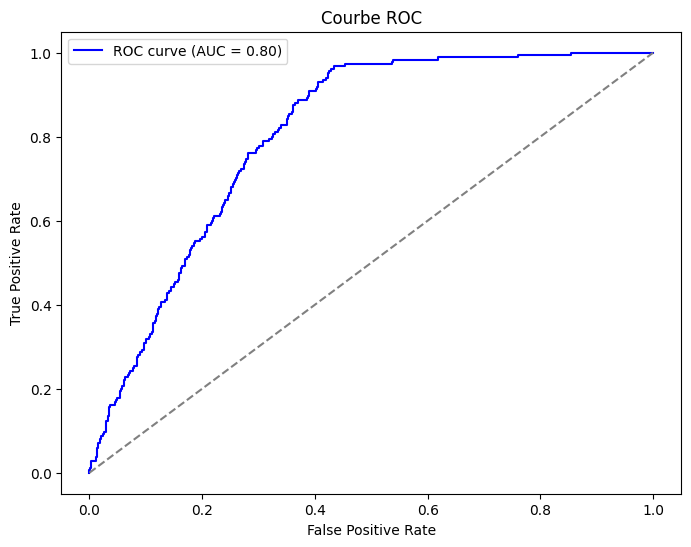

In [19]:
# Regression Logistique

print("\nCréation du pipeline avec préprocessing et modèle...")
pipeline_logReg = Pipeline([
    ('preprocessor', preprocessor),                  # Proprcessor
    ('logistic', LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs'))              # Modèle de régression logistique
])



# Entrainement et prédiction du modèle
pipeline_logReg.fit(X_train, y_train)
y_pred = pipeline_logReg.predict(X_test)

# probabilities
y_prob = pipeline_logReg.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, y_pred))



acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title(f"Confusion Matrix - Accuracy: {acc:.2f}")
plt.show()


# Calcul de la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Tracé de la courbe ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label="ROC curve (AUC = {:.2f})".format(roc_auc_score(y_test, y_prob)))
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Ligne aléatoire
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()
plt.show()

## Modele RandomForest


Création du pipeline avec préprocessing et modèle...
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       1.00      0.01      0.02       185

    accuracy                           0.94      3084
   macro avg       0.97      0.51      0.50      3084
weighted avg       0.94      0.94      0.91      3084



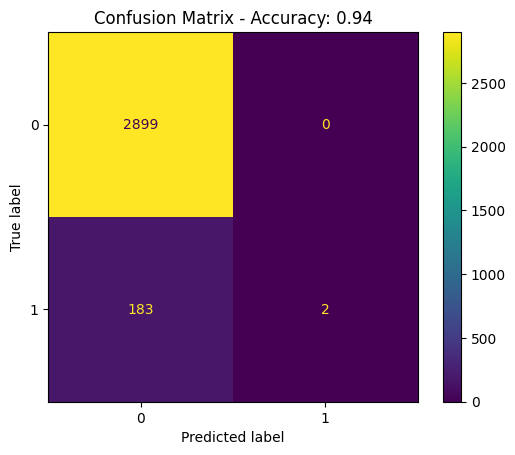

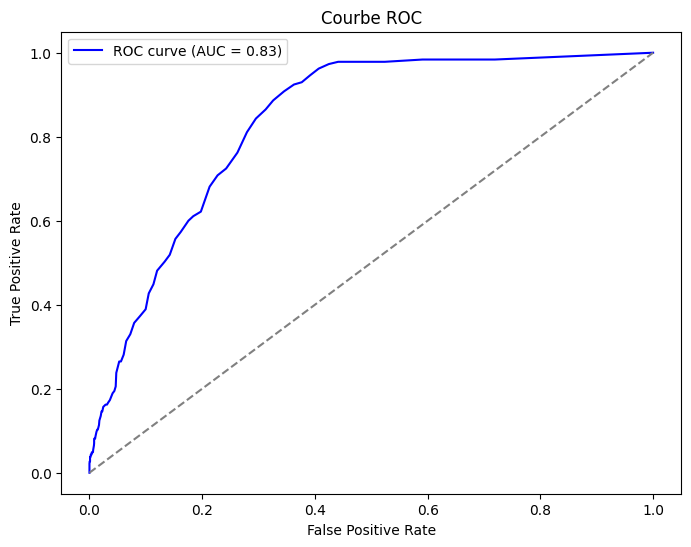

In [20]:
# Modele RandomForest
print("\nCréation du pipeline avec préprocessing et modèle...")


random_preprocessor = ColumnTransformer([
    
   ("num", Pipeline(steps=[('imputer', SimpleImputer())]), numeric_columns),
    
    ("onehot", categoric_one_hot_pipe, categoric_one_hot_columns),

    ("ordinale", ordinal_encoder_pipe, categoric_ordinal_columns)
])

pipeline_random = Pipeline([
    ('preprocessor', random_preprocessor),                  # Proprcessor
    ('random', RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=200,))              # Modèle de foret aléatoire
])

# Entrainement et prédiction du modèle
pipeline_random.fit(X_train, y_train)
y_pred = pipeline_random.predict(X_test)

# probabilities
y_prob = pipeline_random.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, y_pred))



acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title(f"Confusion Matrix - Accuracy: {acc:.2f}")
plt.show()


# Calcul de la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Tracé de la courbe ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label="ROC curve (AUC = {:.2f})".format(roc_auc_score(y_test, y_prob)))
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Ligne aléatoire
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()
plt.show()

# Ne détecte pratiquement pas les cas de fraude. Car le recall est de 0.01 => Detecte 2 cas de fraude sur 185
# Donc risque de ne pas retenir ce modèle. Pour les cas de ce type de fraude , c'est probalement très couteux de
# ne pas detecter les fraudes. Donc un modèle qui detecte mieux les fraudes est préférables dans notre cas.

## Modèle Boost
Modèle utilise est CatBoost car le dataset contient beaucoup de features catégorielles


Création du pipeline avec préprocessing et modèle CatBoost...
Learning rate set to 0.248809
0:	learn: 0.5803373	total: 56.1ms	remaining: 5.56s
1:	learn: 0.5260384	total: 63.4ms	remaining: 3.1s
2:	learn: 0.5044682	total: 69.6ms	remaining: 2.25s
3:	learn: 0.4847455	total: 75.2ms	remaining: 1.8s
4:	learn: 0.4764825	total: 81.3ms	remaining: 1.54s
5:	learn: 0.4688268	total: 86.6ms	remaining: 1.36s
6:	learn: 0.4665743	total: 92.9ms	remaining: 1.23s
7:	learn: 0.4643828	total: 98.2ms	remaining: 1.13s
8:	learn: 0.4622054	total: 103ms	remaining: 1.04s
9:	learn: 0.4543928	total: 108ms	remaining: 976ms
10:	learn: 0.4459848	total: 116ms	remaining: 939ms
11:	learn: 0.4450214	total: 121ms	remaining: 888ms
12:	learn: 0.4416065	total: 126ms	remaining: 846ms
13:	learn: 0.4397044	total: 132ms	remaining: 810ms
14:	learn: 0.4343801	total: 137ms	remaining: 775ms
15:	learn: 0.4263486	total: 141ms	remaining: 741ms
16:	learn: 0.4231964	total: 146ms	remaining: 713ms
17:	learn: 0.4120070	total: 153ms	remaining:

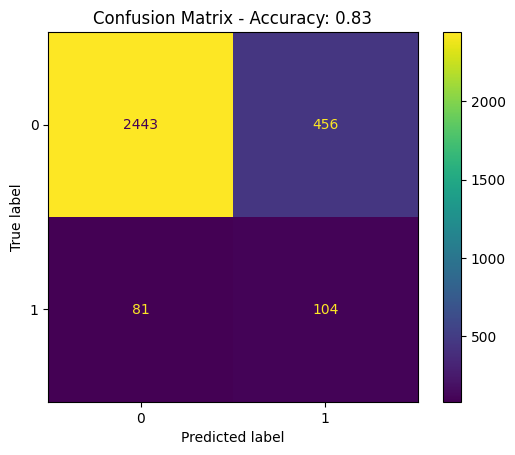

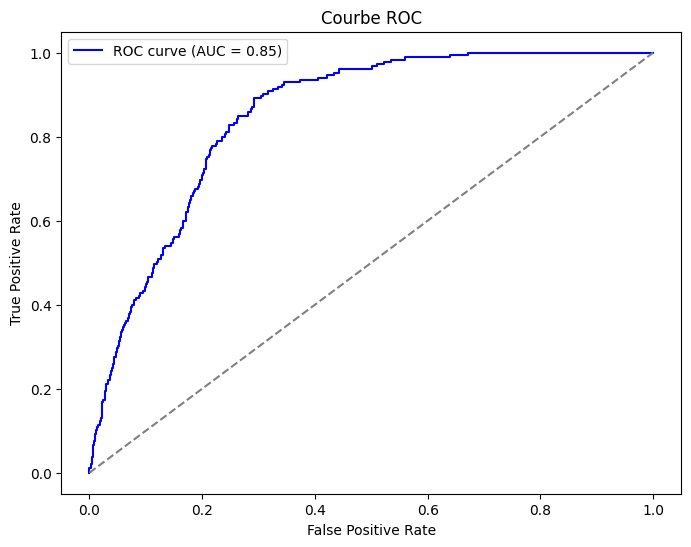

In [21]:
# Modele XGBoost
print("\nCréation du pipeline avec préprocessing et modèle CatBoost...")


boost_preprocessor = ColumnTransformer([
    
   ("num", Pipeline(steps=[('imputer', SimpleImputer())]), numeric_columns),
    
    ("onehot", categoric_one_hot_pipe, categoric_one_hot_columns),

    ("ordinale", ordinal_encoder_pipe, categoric_ordinal_columns)
])

pipeline_boost = Pipeline([
    ('preprocessor', boost_preprocessor),                  # Proprcessor
    ('boosting', CatBoostClassifier(iterations=100, auto_class_weights='Balanced'))              # Modèle Boost
])

# Entrainement et prédiction du modèle
pipeline_boost.fit(X_train, y_train)
y_pred = pipeline_boost.predict(X_test)

# probabilities
y_prob = pipeline_boost.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, y_pred))



acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title(f"Confusion Matrix - Accuracy: {acc:.2f}")
plt.show()


# Calcul de la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Tracé de la courbe ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label="ROC curve (AUC = {:.2f})".format(roc_auc_score(y_test, y_prob)))
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Ligne aléatoire
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()
plt.show()

Après une première phase d’évaluation, deux modèles ont été retenus pour approfondissement : Logistic Regression et CatBoost. Ces modèles présentent les meilleurs résultats sur la classe minoritaire (fraude). Une phase de tuning est ensuite réalisée afin d’évaluer leur potentiel réel et d’identifier le meilleur compromis entre détection des fraudes et limitation des faux positifs.

- GridSearchCV : teste toutes les combinaisons

- RandomizedSearchCV : teste un nombre limité de combinaisons aléatoires - si la grille est trop grande

In [22]:
# GridSearchCV sur moèle RegressionLogistic

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
params = {
    'logistic__C': [0.01, 0.1, 1, 10, 100],
}

print(pipeline_logReg.get_params().keys())
logRegSearch = GridSearchCV(pipeline_logReg, param_grid=params, cv=cv, scoring='roc_auc', n_jobs=-1)
logRegSearch.fit(X_train, y_train)
print(f"Best parameters: {logRegSearch.best_params_}")

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessor', 'logistic', 'preprocessor__force_int_remainder_cols', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num', 'preprocessor__onehot', 'preprocessor__ordinale', 'preprocessor__num__memory', 'preprocessor__num__steps', 'preprocessor__num__transform_input', 'preprocessor__num__verbose', 'preprocessor__num__scaler', 'preprocessor__num__imputer', 'preprocessor__num__scaler__copy', 'preprocessor__num__scaler__with_mean', 'preprocessor__num__scaler__with_std', 'preprocessor__num__imputer__add_indicator', 'preprocessor__num__imputer__copy', 'preprocessor__num__imputer__fill_value', 'preprocessor__num__imputer__keep_empty_features', 'preprocessor__num__imputer__missing_values', 'preprocessor__num__imputer__strategy', 'preprocessor__onehot

In [23]:
# RandomizedSearchCV sur moèle RandomForest

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
params = {
    'random__n_estimators': [10, 50, 100],
    'random__max_depth': [None, 10, 20, 50],
    'random__max_features': [2, 5],
    'random__min_samples_leaf': [1, 2, 4]
}

print(pipeline_random.get_params().keys())
randomSearch = RandomizedSearchCV(pipeline_random, param_distributions=params, n_iter=30, cv=cv, scoring='roc_auc', n_jobs=-1,  random_state=42)
#randomSearch = GridSearchCV(pipeline_random, param_grid=parms, cv=cv, scoring='roc_auc', n_jobs=-1)
randomSearch.fit(X_train, y_train)
print(f"Best parameters: {randomSearch.best_params_}")

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessor', 'random', 'preprocessor__force_int_remainder_cols', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num', 'preprocessor__onehot', 'preprocessor__ordinale', 'preprocessor__num__memory', 'preprocessor__num__steps', 'preprocessor__num__transform_input', 'preprocessor__num__verbose', 'preprocessor__num__imputer', 'preprocessor__num__imputer__add_indicator', 'preprocessor__num__imputer__copy', 'preprocessor__num__imputer__fill_value', 'preprocessor__num__imputer__keep_empty_features', 'preprocessor__num__imputer__missing_values', 'preprocessor__num__imputer__strategy', 'preprocessor__onehot__memory', 'preprocessor__onehot__steps', 'preprocessor__onehot__transform_input', 'preprocessor__onehot__verbose', 'preprocessor__onehot__onehot

In [24]:
# RandomizedSearchCV sur moèle CatBoost

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
params = {
    'boosting__depth': [4,5,6,7,8,9, 10],
    'boosting__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'boosting__iterations': [10, 20,30,40,50,60,70,80,90, 100]
}

print(pipeline_boost.get_params().keys())
boostingSearch = RandomizedSearchCV(pipeline_boost, param_distributions=params, cv=cv, n_iter=30,scoring='roc_auc', n_jobs=-1, random_state=42)
boostingSearch.fit(X_train, y_train)
print(f"Best parameters: {boostingSearch.best_params_}")

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessor', 'boosting', 'preprocessor__force_int_remainder_cols', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num', 'preprocessor__onehot', 'preprocessor__ordinale', 'preprocessor__num__memory', 'preprocessor__num__steps', 'preprocessor__num__transform_input', 'preprocessor__num__verbose', 'preprocessor__num__imputer', 'preprocessor__num__imputer__add_indicator', 'preprocessor__num__imputer__copy', 'preprocessor__num__imputer__fill_value', 'preprocessor__num__imputer__keep_empty_features', 'preprocessor__num__imputer__missing_values', 'preprocessor__num__imputer__strategy', 'preprocessor__onehot__memory', 'preprocessor__onehot__steps', 'preprocessor__onehot__transform_input', 'preprocessor__onehot__verbose', 'preprocessor__onehot__oneh

## Choisir le meilleur modèle

                 Model  Accuracy    Recall        F1   ROC-AUC
2             CatBoost  0.679637  0.940541  0.260479  0.857500
1        Random Forest  0.904669  0.264865  0.250000  0.828219
0  Logistic Regression  0.608949  0.924324  0.220930  0.803966


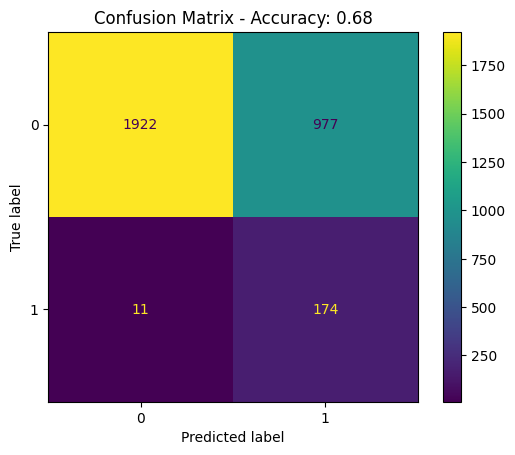

In [25]:
best_logreg = logRegSearch.best_estimator_
best_random = randomSearch.best_estimator_
best_boost = boostingSearch.best_estimator_

models = {
    "Logistic Regression": best_logreg,
    "Random Forest": best_random,
    "CatBoost" : best_boost
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

df_results = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
print(df_results)

# Modèle CatBosst meilleur candidat.
y_pred = best_boost.predict(X_test)
y_proba = best_boost.predict_proba(X_test)[:, 1]
acc= accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=confusion).plot()
plt.title(f"Confusion Matrix - Accuracy: {acc:.2f}")
plt.show()




In [26]:
thresholds = [ 0.5, 0.6, 0.7, 0.8]

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      2899
           1       0.19      0.56      0.28       185

    accuracy                           0.83      3084
   macro avg       0.58      0.70      0.59      3084
weighted avg       0.92      0.83      0.86      3084


Threshold: 0.6
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      2899
           1       0.21      0.50      0.30       185

    accuracy                           0.86      3084
   macro avg       0.59      0.69      0.61      3084
weighted avg       0.92      0.86      0.89      3084


Threshold: 0.7
              precision    recall  f1-score   support

           0       0.96      0.93      0.95      2899
           1       0.26      0.36      0.30       185

    accuracy                           0.90      3084
   macro avg       0.61      0.65      0.62      3084
weighted avg       0.92   

                                 Feature  Importance
14           onehot__Fault_Policy Holder   25.607052
15             onehot__Fault_Third Party    9.186820
5                              num__Year    8.032038
32          onehot__BasePolicy_Liability    7.730201
18  onehot__PolicyType_Sedan - Liability    6.888068
41                       ordinale__Month    6.019982
40         ordinale__AddressChange_Claim    5.150786
3                        num__Deductible    4.503778
44                ordinale__MonthClaimed    4.236754
0                       num__WeekOfMonth    2.453581


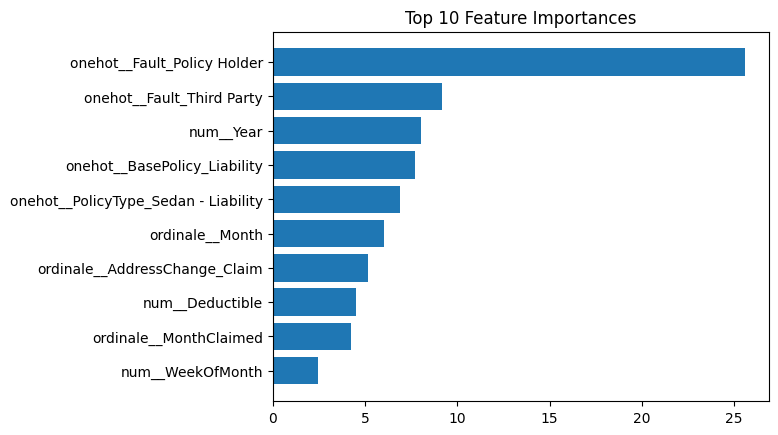

In [27]:
best_boost = boostingSearch.best_estimator_
rf_model = best_boost.named_steps['boosting']
importances = rf_model.feature_importances_
feature_names = best_boost.named_steps['preprocessor'].get_feature_names_out()
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print(feature_importances.head(10))

import matplotlib.pyplot as plt

top10 = feature_importances.head(10)

plt.figure()
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.show()

Certaines variables, notamment liées à la notion de responsabilité ("Fault"), présentent une importance élevée dans le modèle.

Cependant, la documentation du dataset ne précise pas clairement à quel moment ces informations sont disponibles dans le processus métier.

Il existe donc un risque potentiel de data leakage si ces variables sont déterminées après investigation du sinistre.

En l’absence d’information complémentaire sur le dataset Kaggle, cette hypothèse ne peut pas être confirmée.